# Stepping through `MetricsEvaluator` on dumped DC anndatas

Walks each stage of `MetricsEvaluator.__init__` + `.compute()` and inspects intermediate state, so we can see exactly where the pdex↔cell-eval fold-change bug lands.

Set the two paths below to match where `state tx predict --debug-dump-celltype-adatas ...` wrote the per-celltype h5ads.

In [1]:
REAL_H5AD = "/home/leonhafner/arc-in-vivo/debug/celltype_dump_DCs/DCs_adata_real.h5ad"
PRED_H5AD = "/home/leonhafner/arc-in-vivo/debug/celltype_dump_DCs/DCs_adata_pred.h5ad"
CONTROL_PERT = "non-targeting"
PERT_COL = "target_gene_name"

In [2]:
import logging
import numpy as np
import polars as pl
import anndata as ad

logging.basicConfig(level=logging.INFO)

real = ad.read_h5ad(REAL_H5AD)
pred = ad.read_h5ad(PRED_H5AD)
print("real:", real)
print("pred:", pred)

real: AnnData object with n_obs × n_vars = 5867 × 2000
    obs: 'target_gene_name', 'celltype', 'batch'
pred: AnnData object with n_obs × n_vars = 5867 × 2000
    obs: 'target_gene_name', 'celltype', 'batch'


## Stage 1 — `_build_anndata_pair`

Source: `cell_eval/_evaluator.py:154`. Does three things:

1. Casts float16 → float32 (NUMBA compat).
2. `_convert_to_normlog` — if the data looks raw, applies `normalize_total` + `log1p` in place. We expect the dumped anndatas from `state tx predict` to already be log1p; confirm below.
3. Wraps in `PerturbationAnndataPair`, which validates gene-order agreement and perturbation overlap.

In [3]:
from cell_eval.utils import guess_is_lognorm
print("real is lognorm?", guess_is_lognorm(real, validate=False))
print("pred is lognorm?", guess_is_lognorm(pred, validate=False))
print("\nreal.X dtype:", real.X.dtype, "  range:", float(np.asarray(real.X).min()), "to", float(np.asarray(real.X).max()))
print("pred.X dtype:", pred.X.dtype, "  range:", float(np.asarray(pred.X).min()), "to", float(np.asarray(pred.X).max()))

INFO:cell_eval.utils:Data appears to be log1p normalized (decimals detected, range [0.00, 8.12])
INFO:cell_eval.utils:Data appears to be log1p normalized (decimals detected, range [0.00, 8.12])


real is lognorm? True
pred is lognorm? True

real.X dtype: float32   range: 0.0 to 8.121733665466309
pred.X dtype: float32   range: 0.0 to 8.121733665466309


In [4]:
from cell_eval._evaluator import _build_anndata_pair

pair = _build_anndata_pair(
    real=real, pred=pred,
    control_pert=CONTROL_PERT, pert_col=PERT_COL,
    allow_discrete=False,
)
print("perts:", pair.get_perts()[:10], "...", f"(total {len(pair.get_perts())})")
print("control present?", CONTROL_PERT in pair.get_perts())
print("real.X shape:", pair.real.X.shape, " pred.X shape:", pair.pred.X.shape)

INFO:cell_eval.utils:Data appears to be log1p normalized (decimals detected, range [0.00, 8.12])
INFO:cell_eval._evaluator:Input is found to be log-normalized already - skipping transformation.
INFO:cell_eval.utils:Data appears to be log1p normalized (decimals detected, range [0.00, 8.12])
INFO:cell_eval._evaluator:Input is found to be log-normalized already - skipping transformation.


perts: ['Bcl11a' 'Cxxc1' 'Ehmt1' 'Gata2' 'Hcst' 'Kdm1a' 'Kdm5b' 'Ly96' 'Ncoa6'
 'Nup35'] ... (total 15)
control present? False
real.X shape: (5867, 2000)  pred.X shape: (5867, 2000)


## Stage 2 — run `pdex` directly

This is what `_load_or_build_de` does at `_evaluator.py:296`. State uses `exp_post_agg=True, is_log1p=True` and `mode="ref"`.

Remember: pdex's `fold_change` column is already `log2(target_mean / ref_mean)` (see `pdex/_math.py`).

In [5]:
from pdex import pdex

pdex_kwargs = dict(
    reference=CONTROL_PERT,
    groupby=PERT_COL,
    is_log1p=True,
    exp_post_agg=True,
    threads=4,
)

de_real_raw = pdex(adata=pair.real, mode="ref", **pdex_kwargs)
de_pred_raw = pdex(adata=pair.pred, mode="ref", **pdex_kwargs)
print("de_real_raw shape:", de_real_raw.shape)
print("columns:", de_real_raw.columns)
de_real_raw

/tmp/ipykernel_869681/119649610.py:11: UserWarning: Unexpected keyword arguments for mode='ref' (ignored): exp_post_agg
  de_real_raw = pdex(adata=pair.real, mode="ref", **pdex_kwargs)
Running parallel differential expression (against reference): 100%|██████████| 16/16 [00:03<00:00,  4.59it/s]
/tmp/ipykernel_869681/119649610.py:12: UserWarning: Unexpected keyword arguments for mode='ref' (ignored): exp_post_agg
  de_pred_raw = pdex(adata=pair.pred, mode="ref", **pdex_kwargs)
Running parallel differential expression (against reference): 100%|██████████| 16/16 [00:00<00:00, 28.22it/s]

de_real_raw shape: (30000, 11)
columns: ['target', 'feature', 'target_mean', 'ref_mean', 'target_membership', 'ref_membership', 'fold_change', 'percent_change', 'p_value', 'statistic', 'fdr']


target,feature,target_mean,ref_mean,target_membership,ref_membership,fold_change,percent_change,p_value,statistic,fdr
str,str,f32,f32,i32,i32,f64,f64,f64,f64,f64
"""Bcl11a""","""0""",0.0,0.0,14,1990,NaN,NaN,1.0,13930.0,1.0
"""Bcl11a""","""1""",0.0,0.040309,14,1990,-inf,-1.0,0.459722,13405.0,1.0
"""Bcl11a""","""2""",0.0,0.016224,14,1990,-inf,-1.0,0.469195,13426.0,1.0
"""Bcl11a""","""3""",0.0,0.002565,14,1990,-inf,-1.0,0.781727,13853.0,1.0
"""Bcl11a""","""4""",0.0,0.0,14,1990,NaN,NaN,1.0,13930.0,1.0
…,…,…,…,…,…,…,…,…,…,…
"""Smarca2""","""1995""",0.0,0.0,816,1990,NaN,NaN,1.0,811920.0,1.0
"""Smarca2""","""1996""",0.000364,0.000424,816,1990,-0.22041,-0.141679,0.872174,812098.0,1.0
"""Smarca2""","""1997""",39.110416,38.97958,816,1990,0.004834,0.003357,0.017014,765409.5,0.058669


In [6]:
# Verify: `fold_change` == log2(target_mean / ref_mean)
check = de_real_raw.with_columns(
    recomputed=(pl.col("target_mean") / pl.col("ref_mean")).log(base=2)
).select(["target", "feature", "fold_change", "recomputed"])
check

target,feature,fold_change,recomputed
str,str,f64,f32
"""Bcl11a""","""0""",NaN,NaN
"""Bcl11a""","""1""",-inf,-inf
"""Bcl11a""","""2""",-inf,-inf
"""Bcl11a""","""3""",-inf,-inf
"""Bcl11a""","""4""",NaN,NaN
…,…,…,…
"""Smarca2""","""1995""",NaN,NaN
"""Smarca2""","""1996""",-0.22041,-0.22041
"""Smarca2""","""1997""",0.004834,0.004834


In [7]:
# Summary stats — confirms negatives and values < 1 (signature of log2FC, not raw FC)
for name, df in [("real", de_real_raw), ("pred", de_pred_raw)]:
    fc = df["fold_change"].to_numpy()
    fc = fc[np.isfinite(fc)]
    print(f"\n{name}: n={fc.size}, min={fc.min():.3f}, max={fc.max():.3f}, median={np.median(fc):.3f}, "
          f"#<0: {(fc<0).sum()} ({100*(fc<0).sum()/fc.size:.1f}%)")


real: n=15091, min=-6.607, max=9.099, median=0.110, #<0: 6756 (44.8%)

pred: n=20865, min=-5.474, max=6.371, median=0.019, #<0: 10035 (48.1%)


## Stage 3 — `initialize_de_comparison` → `DEResults.__post_init__`

Source: `cell_eval/_types/_de.py:57`. Lines 100–111 add the `log2_fold_change` column by applying `.log(base=2)` on top of `fold_change`.

**This is the bug site.** We'll inspect the transformed frame.

In [8]:
from cell_eval._types._de import initialize_de_comparison

cmp = initialize_de_comparison(real=de_real_raw.clone(), pred=de_pred_raw.clone())
real_tx = cmp.real.data
pred_tx = cmp.pred.data
print("columns after DEResults:", real_tx.columns)
real_tx

INFO:cell_eval._types._de:Checking DE data integrity... (real)
INFO:cell_eval._types._de:DE data integrity check complete. (real)
INFO:cell_eval._types._de:Checking DE data integrity... (pred)
INFO:cell_eval._types._de:DE data integrity check complete. (pred)


columns after DEResults: ['target', 'feature', 'fold_change', 'p_value', 'fdr', 'log2_fold_change', 'abs_log2_fold_change']


target,feature,fold_change,p_value,fdr,log2_fold_change,abs_log2_fold_change
cat,cat,f32,f32,f32,f32,f32
"""Bcl11a""","""0""",NaN,1.0,1.0,0.0,0.0
"""Bcl11a""","""1""",-inf,0.459722,1.0,0.0,0.0
"""Bcl11a""","""2""",-inf,0.469195,1.0,0.0,0.0
"""Bcl11a""","""3""",-inf,0.781727,1.0,0.0,0.0
"""Bcl11a""","""4""",NaN,1.0,1.0,0.0,0.0
…,…,…,…,…,…,…
"""Smarca2""","""1995""",NaN,1.0,1.0,0.0,0.0
"""Smarca2""","""1996""",-0.22041,0.872174,1.0,0.0,0.0
"""Smarca2""","""1997""",0.004834,0.017014,0.058669,-7.692461,7.692461


In [9]:
# What happened to the values?
pl.DataFrame({
    "pdex fold_change (true log2FC)": de_real_raw["fold_change"],
    "cell-eval log2_fold_change": real_tx["log2_fold_change"],
    "cell-eval abs_log2_fold_change": real_tx["abs_log2_fold_change"],
}).head(12)

pdex fold_change (true log2FC),cell-eval log2_fold_change,cell-eval abs_log2_fold_change
f64,f32,f32
NaN,0.0,0.0
-inf,0.0,0.0
-inf,0.0,0.0
-inf,0.0,0.0
NaN,0.0,0.0
…,…,…
0.614612,-0.702251,0.702251
-0.105508,0.0,0.0
NaN,0.0,0.0


In [10]:
# Stats on the corrupted column
l2 = real_tx["log2_fold_change"].to_numpy()
fc = de_real_raw["fold_change"].to_numpy()
print(f"pdex fold_change negatives: {(fc<0).sum()} / {fc.size}")
print(f"cell-eval log2_fold_change zeros: {(l2==0).sum()} / {l2.size}")
print(f"\nAre the zero positions the same as the negative pdex positions? {np.array_equal(fc<0, l2==0) or ((fc<0).sum() and (l2==0).sum()>= (fc<0).sum())}")
# Show the rows where fold_change is negative
print("\nSample of downregulated (negative FC) rows — all zeroed in log2_fold_change:")
real_tx.with_columns(raw_fc=pl.Series(fc)).filter(pl.col("raw_fc") < 0)

pdex fold_change negatives: 13985 / 30000
cell-eval log2_fold_change zeros: 21432 / 30000

Are the zero positions the same as the negative pdex positions? True

Sample of downregulated (negative FC) rows — all zeroed in log2_fold_change:


target,feature,fold_change,p_value,fdr,log2_fold_change,abs_log2_fold_change,raw_fc
cat,cat,f32,f32,f32,f32,f32,f64
"""Bcl11a""","""1""",-inf,0.459722,1.0,0.0,0.0,-inf
"""Bcl11a""","""2""",-inf,0.469195,1.0,0.0,0.0,-inf
"""Bcl11a""","""3""",-inf,0.781727,1.0,0.0,0.0,-inf
"""Bcl11a""","""8""",-0.105508,0.359653,1.0,0.0,0.0,-0.105508
"""Bcl11a""","""10""",-0.283647,0.581937,1.0,0.0,0.0,-0.283647
…,…,…,…,…,…,…,…
"""Smarca2""","""1988""",-0.09514,0.704434,1.0,0.0,0.0,-0.09514
"""Smarca2""","""1991""",-0.651035,0.000013,0.000087,0.0,0.0,-0.651035
"""Smarca2""","""1992""",-0.935632,0.291312,0.601906,0.0,0.0,-0.935632


## Stage 4 — ranking: true vs. corrupted

This is how `overlap_at_N` / `precision_at_N` pick their top-N genes. Cell-eval's real ranking path (`_de.py:161`) applies `fdr < fdr_threshold` **before** sorting. We mirror that here so the comparison matches what cell-eval actually computes — otherwise `NaN` fold_change rows (zero-expression genes with `fdr=1`) float to the top under polars' descending sort.

In [11]:
# Pick a perturbation that has signal
perts = cmp.real.get_perts()
pert = next(p for p in perts if p != CONTROL_PERT and p == "Smarca2")
print("Inspecting:", pert)

Inspecting: Smarca2


In [12]:
FDR_THRESHOLD = 0.05

# What a FIXED cell-eval would rank on: |true log2FC| from pdex's fold_change.
# FDR filter matches cell-eval's get_top_genes at _de.py:161.
true_top = (
    de_real_raw
        .filter(pl.col("target") == pert)
        .filter(pl.col("fdr") < FDR_THRESHOLD)
        .with_columns(abs_true=pl.col("fold_change").abs())
        .sort("abs_true", descending=True, nulls_last=True)
        .select(["feature", "fold_change", "abs_true", "p_value", "fdr"])
        .head(10)
)
true_top

feature,fold_change,abs_true,p_value,fdr
str,f64,f64,f64,f64
"""261""",inf,inf,0.006823,0.026193
"""836""",inf,inf,0.006823,0.026193
"""857""",inf,inf,0.000129,0.000696
"""1456""",-inf,inf,0.001039,0.004779
"""1824""",-inf,inf,0.008107,0.030591
"""578""",-5.970148,5.970148,0.000001,0.000009
"""669""",-5.242235,5.242235,3.1622e-7,0.000003
"""1794""",4.602383,4.602383,0.000002,0.000013
"""1900""",-4.491631,4.491631,0.00024,0.001217


In [13]:
# What BUGGY cell-eval actually ranks on: abs_log2_fold_change (= |log2(log2FC)|).
# Same FDR filter as real code.
corrupt_top = (
    real_tx
        .filter(pl.col("target") == pert)
        .filter(pl.col("fdr") < FDR_THRESHOLD)
        .sort("abs_log2_fold_change", descending=True, nulls_last=True)
        .select(["feature", "fold_change", "log2_fold_change", "abs_log2_fold_change", "fdr"])
        .head(10)
)
corrupt_top

feature,fold_change,log2_fold_change,abs_log2_fold_change,fdr
cat,f32,f32,f32,f32
"""261""",inf,inf,inf,0.026193
"""836""",inf,inf,inf,0.026193
"""857""",inf,inf,inf,0.000696
"""1655""",0.015986,-5.96702,5.96702,0.023778
"""1191""",0.032225,-4.955661,4.955661,0.000034
"""237""",0.05364,-4.220551,4.220551,0.046822
"""371""",0.055531,-4.170554,4.170554,0.045604
"""1486""",0.092534,-3.43388,3.43388,0.048897
"""987""",0.116229,-3.104957,3.104957,0.026199


In [14]:
true_set = set(true_top["feature"].to_list())
corrupt_set = set(corrupt_top["feature"].to_list())
print("intersection of top-10 sets:", true_set & corrupt_set)
print(f"Jaccard: {len(true_set & corrupt_set) / max(len(true_set | corrupt_set), 1):.2f}")

intersection of top-10 sets: {'261', '857', '836'}
Jaccard: 0.18


## Stage 5 — run the full evaluator end-to-end and look at the metrics it produces

In [15]:
import tempfile, os
from cell_eval import MetricsEvaluator

with tempfile.TemporaryDirectory() as tmp:
    evaluator = MetricsEvaluator(
        adata_pred=pred.copy(),
        adata_real=real.copy(),
        control_pert=CONTROL_PERT,
        pert_col=PERT_COL,
        outdir=tmp,
        pdex_kwargs=dict(exp_post_agg=True, is_log1p=True),
    )
    results, agg = evaluator.compute(profile="de", write_csv=False,
                                     skip_metrics=["pearson_edistance", "clustering_agreement"])
results.head()

INFO:cell_eval.utils:Data appears to be log1p normalized (decimals detected, range [0.00, 8.12])
INFO:cell_eval._evaluator:Input is found to be log-normalized already - skipping transformation.
INFO:cell_eval.utils:Data appears to be log1p normalized (decimals detected, range [0.00, 8.12])
INFO:cell_eval._evaluator:Input is found to be log-normalized already - skipping transformation.
INFO:cell_eval._evaluator:Computing DE for real data
INFO:cell_eval._evaluator:Using the following pdex kwargs: {'exp_post_agg': True, 'is_log1p': True, 'reference': 'non-targeting', 'groupby': 'target_gene_name', 'threads': 4}
/home/leonhafner/libs/cell-eval/src/cell_eval/_evaluator.py:296: UserWarning: Unexpected keyword arguments for mode='ref' (ignored): exp_post_agg
  frame = pdex(
Running parallel differential expression (against reference): 100%|██████████| 16/16 [00:00<00:00, 23.99it/s]
INFO:cell_eval._evaluator:Writing real DE results to: real_de.csv
INFO:cell_eval._evaluator:Computing DE for pre

perturbation,overlap_at_N,overlap_at_50,overlap_at_100,overlap_at_200,overlap_at_500,precision_at_N,precision_at_50,precision_at_100,precision_at_200,precision_at_500,de_spearman_sig,de_direction_match,de_spearman_lfc_sig,de_sig_genes_recall,de_nsig_counts_real,de_nsig_counts_pred,pr_auc,roc_auc
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""Bcl11a""",0.0,0.0,0.0,0.0,0.0,0.050539,0.0,0.0,0.01,0.064,0.890682,0.484375,0.283929,0.953125,64.0,1207.0,0.05797,0.723407
"""Cxxc1""",0.0,0.0,0.0,0.0,0.0,0.040913,0.0,0.0,0.005,0.028,0.890682,0.483871,0.228708,0.83871,62.0,1271.0,0.041592,0.625483
"""Ehmt1""",0.021429,0.0,0.0,0.021429,0.021429,0.069732,0.0,0.0,0.035,0.058,0.890682,0.607143,0.646277,0.65,140.0,1305.0,0.059434,0.459783
"""Gata2""",0.092233,0.02,0.02,0.085,0.092233,0.127989,0.02,0.02,0.085,0.146,0.890682,0.606796,0.631666,0.883495,206.0,1422.0,0.116804,0.574554
"""Hcst""",0.125448,0.0,0.01,0.08,0.125448,0.180384,0.0,0.01,0.08,0.164,0.890682,0.713262,0.60584,0.942652,279.0,1458.0,0.170867,0.608911


In [16]:
# Aggregated view
agg

statistic,overlap_at_N,overlap_at_50,overlap_at_100,overlap_at_200,overlap_at_500,precision_at_N,precision_at_50,precision_at_100,precision_at_200,precision_at_500,de_spearman_sig,de_direction_match,de_spearman_lfc_sig,de_sig_genes_recall,de_nsig_counts_real,de_nsig_counts_pred,pr_auc,roc_auc
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""",15.0,15.0,15.0,15.0,15.0,15.0,15.0,15.0,15.0,15.0,15.0,15.0,15.0,15.0,15.0,15.0,15.0,15.0
"""null_count""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",0.122401,0.009587,0.012663,0.047424,0.117137,0.153777,0.009333,0.011333,0.05,0.149067,0.890682,0.567745,0.458831,0.888073,239.2,1307.333333,0.146061,0.629919
"""std""",0.150725,0.010651,0.012878,0.044681,0.142683,0.129161,0.010328,0.012459,0.042258,0.124609,2.2984e-16,0.099883,0.239781,0.089883,207.699027,131.540687,0.119342,0.083991
"""min""",0.0,0.0,0.0,0.0,0.0,0.033599,0.0,0.0,0.005,0.028,0.890682,0.40708,-0.060854,0.65,42.0,1116.0,0.031481,0.459783
"""25%""",0.016129,0.0,0.0,0.016129,0.016129,0.052768,0.0,0.0,0.015,0.058,0.890682,0.487273,0.283929,0.883495,64.0,1207.0,0.05797,0.607576
"""50%""",0.02381,0.0,0.01,0.02381,0.02381,0.093722,0.0,0.01,0.035,0.092,0.890682,0.606796,0.507282,0.918681,140.0,1305.0,0.106308,0.61699
"""75%""",0.301099,0.02,0.02,0.085,0.28,0.292512,0.02,0.02,0.085,0.28,0.890682,0.645161,0.646277,0.942652,455.0,1431.0,0.271614,0.723407
"""max""",0.399299,0.02381,0.04,0.125,0.388,0.367575,0.02,0.04,0.125,0.388,0.890682,0.713262,0.7496,0.983871,588.0,1458.0,0.347356,0.758862


## Stage 6 — patch the bug and compare

Monkey-patch `DEResults.__post_init__` so `log2_fold_change` is aliased from pdex's `fold_change` instead of re-logged, then recompute and diff.

In [17]:
from cell_eval._types import _de as _de_mod
import polars as pl

_orig_post_init = _de_mod.DEResults.__post_init__

def _patched_post_init(self):
    required = {self.target_col, self.feature_col, self.fold_change_col, self.pvalue_col, self.fdr_col}
    missing = required - set(self.data.columns)
    if missing:
        raise ValueError(f"Missing required columns: {missing}")
    if self.log2_fold_change_col not in self.data.columns:
        self.data = self.data.with_columns(
            pl.col(self.fold_change_col).alias(self.log2_fold_change_col)
        ).with_columns(
            pl.col(self.log2_fold_change_col).abs().alias(self.abs_log2_fold_change_col)
        )
    numeric_cols = [self.fold_change_col, self.pvalue_col, self.fdr_col,
                    self.log2_fold_change_col, self.abs_log2_fold_change_col]
    categorical_cols = [self.target_col, self.feature_col]
    self.data = self.data.with_columns(
        [pl.col(c).cast(pl.Float32) for c in numeric_cols]
        + [pl.col(c).cast(pl.Categorical) for c in categorical_cols]
    ).drop([c for c in self.data.columns if c not in numeric_cols + categorical_cols])

_de_mod.DEResults.__post_init__ = _patched_post_init
print("patched.")

patched.


In [18]:
with tempfile.TemporaryDirectory() as tmp:
    evaluator_fixed = MetricsEvaluator(
        adata_pred=pred.copy(),
        adata_real=real.copy(),
        control_pert=CONTROL_PERT,
        pert_col=PERT_COL,
        outdir=tmp,
        pdex_kwargs=dict(exp_post_agg=True, is_log1p=True),
    )
    results_fixed, agg_fixed = evaluator_fixed.compute(
        profile="de", write_csv=False,
        skip_metrics=["pearson_edistance", "clustering_agreement"],
    )

# Diff buggy vs. fixed aggregate metrics
diff = (
    agg.rename({c: f"{c}_buggy" for c in agg.columns if c != "statistic"})
       .join(agg_fixed.rename({c: f"{c}_fixed" for c in agg_fixed.columns if c != "statistic"}),
             on="statistic", how="inner")
)
diff

INFO:cell_eval.utils:Data appears to be log1p normalized (decimals detected, range [0.00, 8.12])
INFO:cell_eval._evaluator:Input is found to be log-normalized already - skipping transformation.
INFO:cell_eval.utils:Data appears to be log1p normalized (decimals detected, range [0.00, 8.12])
INFO:cell_eval._evaluator:Input is found to be log-normalized already - skipping transformation.
INFO:cell_eval._evaluator:Computing DE for real data
INFO:cell_eval._evaluator:Using the following pdex kwargs: {'exp_post_agg': True, 'is_log1p': True, 'reference': 'non-targeting', 'groupby': 'target_gene_name', 'threads': 4}
/home/leonhafner/libs/cell-eval/src/cell_eval/_evaluator.py:296: UserWarning: Unexpected keyword arguments for mode='ref' (ignored): exp_post_agg
  frame = pdex(
Running parallel differential expression (against reference): 100%|██████████| 16/16 [00:00<00:00, 28.59it/s]
INFO:cell_eval._evaluator:Writing real DE results to: real_de.csv
INFO:cell_eval._evaluator:Computing DE for pre

statistic,overlap_at_N_buggy,overlap_at_50_buggy,overlap_at_100_buggy,overlap_at_200_buggy,overlap_at_500_buggy,precision_at_N_buggy,precision_at_50_buggy,precision_at_100_buggy,precision_at_200_buggy,precision_at_500_buggy,de_spearman_sig_buggy,de_direction_match_buggy,de_spearman_lfc_sig_buggy,de_sig_genes_recall_buggy,de_nsig_counts_real_buggy,de_nsig_counts_pred_buggy,pr_auc_buggy,roc_auc_buggy,overlap_at_N_fixed,overlap_at_50_fixed,overlap_at_100_fixed,overlap_at_200_fixed,overlap_at_500_fixed,precision_at_N_fixed,precision_at_50_fixed,precision_at_100_fixed,precision_at_200_fixed,precision_at_500_fixed,de_spearman_sig_fixed,de_direction_match_fixed,de_spearman_lfc_sig_fixed,de_sig_genes_recall_fixed,de_nsig_counts_real_fixed,de_nsig_counts_pred_fixed,pr_auc_fixed,roc_auc_fixed
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""",15.0,15.0,15.0,15.0,15.0,15.0,15.0,15.0,15.0,15.0,15.0,15.0,15.0,15.0,15.0,15.0,15.0,15.0,15.0,15.0,15.0,15.0,15.0,15.0,15.0,15.0,15.0,15.0,15.0,15.0,15.0,15.0,15.0,15.0,15.0,15.0
"""null_count""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",0.122401,0.009587,0.012663,0.047424,0.117137,0.153777,0.009333,0.011333,0.05,0.149067,0.890682,0.567745,0.458831,0.888073,239.2,1307.333333,0.146061,0.629919,0.064615,0.013333,0.013742,0.039592,0.059709,0.153777,0.013333,0.014,0.065333,0.101333,0.890682,0.762268,0.458831,0.888073,239.2,1307.333333,0.146061,0.629919
"""std""",0.150725,0.010651,0.012878,0.044681,0.142683,0.129161,0.010328,0.012459,0.042258,0.124609,2.2984e-16,0.099883,0.239781,0.089883,207.699027,131.540687,0.119342,0.083991,0.080306,0.017995,0.012894,0.046788,0.07251,0.129161,0.017995,0.012421,0.040065,0.048836,2.2984e-16,0.08732,0.239781,0.089883,207.699027,131.540687,0.119342,0.083991
"""min""",0.0,0.0,0.0,0.0,0.0,0.033599,0.0,0.0,0.005,0.028,0.890682,0.40708,-0.060854,0.65,42.0,1116.0,0.031481,0.459783,0.0,0.0,0.0,0.0,0.0,0.033599,0.0,0.0,0.015,0.042,0.890682,0.518707,-0.060854,0.65,42.0,1116.0,0.031481,0.459783
"""25%""",0.016129,0.0,0.0,0.016129,0.016129,0.052768,0.0,0.0,0.015,0.058,0.890682,0.487273,0.283929,0.883495,64.0,1207.0,0.05797,0.607576,0.0,0.0,0.0,0.0,0.0,0.052768,0.0,0.01,0.04,0.074,0.890682,0.738095,0.283929,0.883495,64.0,1207.0,0.05797,0.607576
"""50%""",0.02381,0.0,0.01,0.02381,0.02381,0.093722,0.0,0.01,0.035,0.092,0.890682,0.606796,0.507282,0.918681,140.0,1305.0,0.106308,0.61699,0.028571,0.0,0.01,0.028571,0.028571,0.093722,0.0,0.01,0.065,0.086,0.890682,0.76,0.507282,0.918681,140.0,1305.0,0.106308,0.61699
"""75%""",0.301099,0.02,0.02,0.085,0.28,0.292512,0.02,0.02,0.085,0.28,0.890682,0.645161,0.646277,0.942652,455.0,1431.0,0.271614,0.723407,0.152098,0.02,0.02,0.065,0.126,0.292512,0.02,0.02,0.095,0.126,0.890682,0.82,0.646277,0.942652,455.0,1431.0,0.271614,0.723407
"""max""",0.399299,0.02381,0.04,0.125,0.388,0.367575,0.02,0.04,0.125,0.388,0.890682,0.713262,0.7496,0.983871,588.0,1458.0,0.347356,0.758862,0.215412,0.06,0.04,0.14,0.198,0.367575,0.06,0.04,0.14,0.198,0.890682,0.880734,0.7496,0.983871,588.0,1458.0,0.347356,0.758862


In [19]:
# Restore original
_de_mod.DEResults.__post_init__ = _orig_post_init
print("restored.")

restored.


## Stage 7 — Compare buggy vs fixed

Both runs produced:
- `results` / `results_fixed` — per-perturbation values (one row per pert, one column per metric)
- `agg` / `agg_fixed` — `.describe()`-style summary (rows = statistic like `mean`, `std`, …; columns = metric)

We'll (a) summarise the mean-over-perts change per metric, (b) rank metrics by how much they moved, and (c) drill into the most-affected metrics at the perturbation level.

In [20]:
# (a) Per-metric comparison at the mean-over-perturbations level
def _long_mean(agg_df: pl.DataFrame, label: str) -> pl.DataFrame:
    """Melt the describe() frame and keep the 'mean' row."""
    stat_col = "statistic" if "statistic" in agg_df.columns else agg_df.columns[0]
    mean_row = agg_df.filter(pl.col(stat_col) == "mean").drop(stat_col)
    return (
        mean_row.unpivot(variable_name="metric", value_name=label)
                .with_columns(pl.col(label).cast(pl.Float64, strict=False))
    )

buggy_mean = _long_mean(agg, "buggy")
fixed_mean = _long_mean(agg_fixed, "fixed")

comparison = (
    buggy_mean.join(fixed_mean, on="metric", how="inner")
              .with_columns(
                  abs_diff=(pl.col("fixed") - pl.col("buggy")).abs(),
                  rel_diff=(pl.col("fixed") - pl.col("buggy")) / pl.col("buggy").abs(),
              )
              .sort("abs_diff", descending=True, nulls_last=True)
)
comparison

metric,buggy,fixed,abs_diff,rel_diff
str,f64,f64,f64,f64
"""de_direction_match""",0.567745,0.762268,0.194523,0.342624
"""overlap_at_N""",0.122401,0.064615,0.057786,-0.472105
"""overlap_at_500""",0.117137,0.059709,0.057428,-0.490264
"""precision_at_500""",0.149067,0.101333,0.047733,-0.320215
"""precision_at_200""",0.05,0.065333,0.015333,0.306667
…,…,…,…,…
"""de_sig_genes_recall""",0.888073,0.888073,0.0,0.0
"""de_nsig_counts_real""",239.2,239.2,0.0,0.0
"""de_nsig_counts_pred""",1307.333333,1307.333333,0.0,0.0


In [21]:
# (b) Which metrics actually changed? (non-trivial diff)
moved = comparison.filter(pl.col("abs_diff") > 1e-6)
unchanged = comparison.filter(pl.col("abs_diff") <= 1e-6)
print(f"Metrics that moved: {moved.height}")
print(f"Metrics essentially unchanged: {unchanged.height}")
print("\nUnchanged metrics (sanity check — should be the p-value/fdr-only and AnnData-based ones):")
print(unchanged["metric"].to_list())

Metrics that moved: 10
Metrics essentially unchanged: 8

Unchanged metrics (sanity check — should be the p-value/fdr-only and AnnData-based ones):
['precision_at_N', 'de_spearman_sig', 'de_spearman_lfc_sig', 'de_sig_genes_recall', 'de_nsig_counts_real', 'de_nsig_counts_pred', 'pr_auc', 'roc_auc']


In [22]:
# (c) Per-perturbation view of the metrics that moved most
# `results` / `results_fixed` are pivoted: rows = perturbation, columns = metric value.
pert_col_name = results.columns[0]  # typically "target" or perturbation id column

top_moved_metrics = moved["metric"].to_list()[:8]  # focus on top-8 biggest movers
print("Drilling into:", top_moved_metrics)

per_pert = (
    results.select([pert_col_name, *top_moved_metrics])
           .rename({m: f"{m}__buggy" for m in top_moved_metrics})
           .join(
               results_fixed.select([pert_col_name, *top_moved_metrics])
                            .rename({m: f"{m}__fixed" for m in top_moved_metrics}),
               on=pert_col_name, how="inner",
           )
)
per_pert

Drilling into: ['de_direction_match', 'overlap_at_N', 'overlap_at_500', 'precision_at_500', 'precision_at_200', 'overlap_at_200', 'precision_at_50', 'overlap_at_50']


perturbation,de_direction_match__buggy,overlap_at_N__buggy,overlap_at_500__buggy,precision_at_500__buggy,precision_at_200__buggy,overlap_at_200__buggy,precision_at_50__buggy,overlap_at_50__buggy,de_direction_match__fixed,overlap_at_N__fixed,overlap_at_500__fixed,precision_at_500__fixed,precision_at_200__fixed,overlap_at_200__fixed,precision_at_50__fixed,overlap_at_50__fixed
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""Bcl11a""",0.484375,0.0,0.0,0.064,0.01,0.0,0.0,0.0,0.734375,0.0,0.0,0.074,0.1,0.0,0.0,0.0
"""Cxxc1""",0.483871,0.0,0.0,0.028,0.005,0.0,0.0,0.0,0.758065,0.0,0.0,0.052,0.015,0.0,0.0,0.0
"""Ehmt1""",0.607143,0.021429,0.021429,0.058,0.035,0.021429,0.0,0.0,0.835714,0.028571,0.028571,0.042,0.02,0.028571,0.02,0.02
"""Gata2""",0.606796,0.092233,0.092233,0.146,0.085,0.085,0.02,0.02,0.699029,0.063107,0.063107,0.08,0.065,0.065,0.02,0.02
"""Hcst""",0.713262,0.125448,0.125448,0.164,0.08,0.08,0.0,0.0,0.752688,0.043011,0.043011,0.088,0.03,0.03,0.04,0.04
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""P2ry13""",0.5,0.02381,0.02381,0.032,0.005,0.02381,0.02,0.02381,0.738095,0.0,0.0,0.048,0.015,0.0,0.0,0.0
"""Pa2g4""",0.622378,0.370629,0.358,0.358,0.115,0.115,0.0,0.0,0.695804,0.152098,0.126,0.126,0.04,0.04,0.0,0.0
"""Paxip1""",0.56,0.02,0.02,0.048,0.01,0.02,0.02,0.02,0.82,0.0,0.0,0.064,0.075,0.0,0.0,0.0


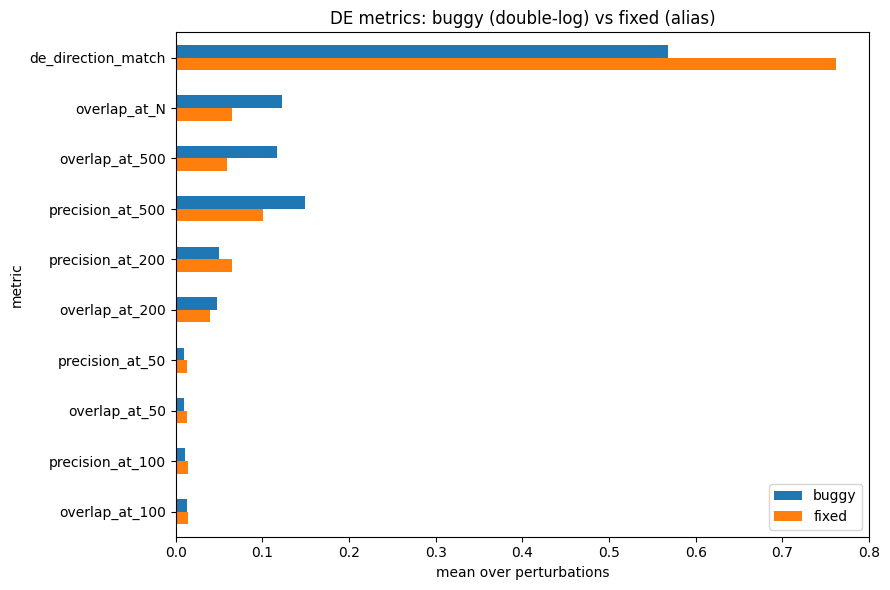

In [23]:
# (d) Quick plot of the biggest movers (buggy vs fixed, mean over perturbations)
import matplotlib.pyplot as plt

plot_df = moved.head(12).to_pandas().set_index("metric")[["buggy", "fixed"]]
ax = plot_df.plot(kind="barh", figsize=(9, 6))
ax.invert_yaxis()
ax.set_xlabel("mean over perturbations")
ax.set_title("DE metrics: buggy (double-log) vs fixed (alias)")
plt.tight_layout()
plt.show()

In [24]:
moved

metric,buggy,fixed,abs_diff,rel_diff
str,f64,f64,f64,f64
"""de_direction_match""",0.567745,0.762268,0.194523,0.342624
"""overlap_at_N""",0.122401,0.064615,0.057786,-0.472105
"""overlap_at_500""",0.117137,0.059709,0.057428,-0.490264
"""precision_at_500""",0.149067,0.101333,0.047733,-0.320215
"""precision_at_200""",0.05,0.065333,0.015333,0.306667
"""overlap_at_200""",0.047424,0.039592,0.007833,-0.165164
"""precision_at_50""",0.009333,0.013333,0.004,0.428571
"""overlap_at_50""",0.009587,0.013333,0.003746,0.390728
"""precision_at_100""",0.011333,0.014,0.002667,0.235294


In [25]:
unchanged

metric,buggy,fixed,abs_diff,rel_diff
str,f64,f64,f64,f64
"""precision_at_N""",0.153777,0.153777,0.0,0.0
"""de_spearman_sig""",0.890682,0.890682,0.0,0.0
"""de_spearman_lfc_sig""",0.458831,0.458831,0.0,0.0
"""de_sig_genes_recall""",0.888073,0.888073,0.0,0.0
"""de_nsig_counts_real""",239.2,239.2,0.0,0.0
"""de_nsig_counts_pred""",1307.333333,1307.333333,0.0,0.0
"""pr_auc""",0.146061,0.146061,0.0,0.0
"""roc_auc""",0.629919,0.629919,0.0,0.0
